In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit as curve_fit

In [52]:
h = 6.626e-34  # Planck's constant (J·s)
e = 1.602e-19  # Elementary charge (C)
c = 299792458  # Speed of light (m/s)
I = 0.014
R = 100

colors = ['red', 'orange1', 'orange2', 'orange3', 'yellow', 'green', 'blue', 'violet']

V = [4,8,12,16,20]
l = [649.23e-9, 610.33e-9, 610.62e-9, 608.17e-9, 591.01e-9, 572.36e-9, 456.39e-9, 404e-9]

V_o = [1.47, 1.56, 1.57, 1.59, 1.61, 1.72, 2.31, 2.94]

In [53]:
def lin(x, m, b):
    return m*x + b

def fitting(x, y):
    params, cov = curve_fit(lin, x, y)
    return params, cov

def linreg(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    # Fit linear regression using least squares
    m, b = np.polyfit(x, y, 1)

    # Predicted values
    y_pred = m * x + b

    # Compute R^2
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    return m, b, r2


[3.05966271846341e-19, 3.2546734171808693e-19, 3.2531276844977235e-19, 3.2662328406662614e-19, 3.3610680474239013e-19, 3.4705863909217976e-19, 4.352472286220118e-19, 4.916893135415841e-19]
[2.35494e-19, 2.49912e-19, 2.51514e-19, 2.54718e-19, 2.5792200000000004e-19, 2.75544e-19, 3.70062e-19, 4.70988e-19]


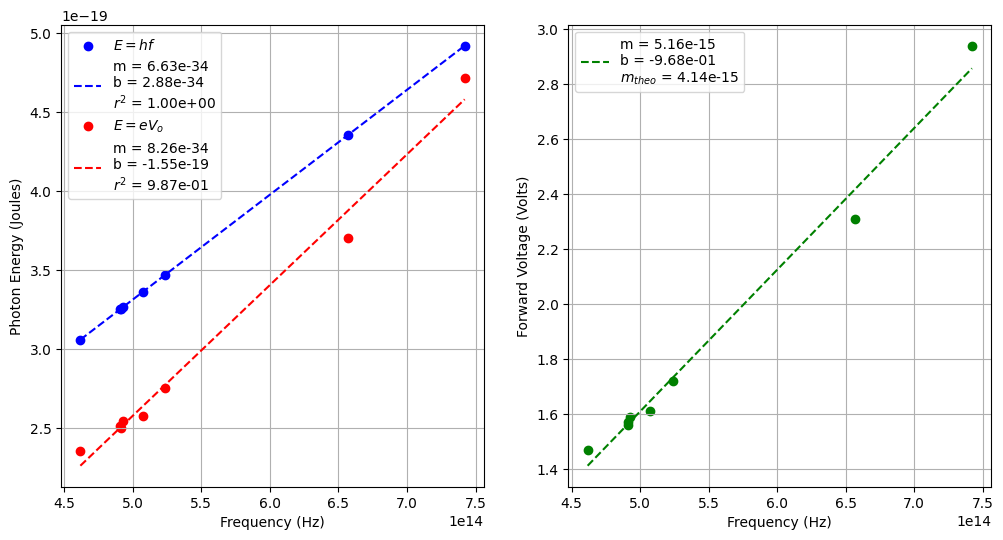

In [54]:
# E = hf Calculation
f = [c/i for i in l]
E_hf = [h*i for i in f]

# E = eV_o Calculation
E_eV = [e*i for i in V_o]

print(E_hf)
print(E_eV)

# Plotting
domain = np.linspace(min(f), max(f), 100)

m_hf, b_hf, r2_hf = linreg(f, E_hf)
m_eV, b_eV, r2_eV = linreg(f, E_eV)
m_he, b_he, r2_he = linreg(f, V_o)

m_theo = h/e 


fig, ax = plt.subplots(1,2, figsize=(12, 6))
ax[0].scatter(f, E_hf, color='blue', label=f'$E = hf$')
ax[0].plot(domain, lin(domain, m_hf, b_hf), color='blue', label=f'm = {m_hf:.2e}\nb = {b_hf:.2e}\n$r^2$ = {r2_hf:.2e}', linestyle='--')
ax[0].scatter(f, E_eV, color='red', label=f'$E = eV_o$')
ax[0].plot(domain, lin(domain, m_eV, b_eV), color='red', label=f'm = {m_eV:.2e}\nb = {b_eV:.2e}\n$r^2$ = {r2_eV:.2e}', linestyle='--')
ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel('Photon Energy (Joules)')
ax[0].grid()
ax[0].legend()

ax[1].scatter(f, V_o, color='green')
ax[1].plot(domain, lin(domain, m_he, b_he), color='green', linestyle='--', label=f'm = {m_he:.2e}\nb = {b_he:.2e}\n$m_{{theo}}$ = {m_theo:.2e}')
ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_ylabel('Forward Voltage (Volts)')
ax[1].grid()
ax[1].legend()

plt.savefig('photoelectric_effect.png', dpi=300)

In [55]:
err = (m_eV - m_hf)/m_hf * 100
print(f'Percentage Error between E=hf and E=eV_o slopes: {err:.2f}%')

err2 = (m_he - m_theo)/m_theo * 100
print(f'Percentage Error between experimental and theoretical slopes in V_o vs f: {err2:.2f}%')

Percentage Error between E=hf and E=eV_o slopes: 24.63%
Percentage Error between experimental and theoretical slopes in V_o vs f: 24.63%


In [56]:
# Obtaining Planck's Constant
# h = eV_o / f
L =     [649.38e-9, 649.08e-9, 
        610.2e-9, 609.8e-9, 609.4e-9, 612.05e-9, 610.2e-9, 
        610e-9, 609.17e-9, 609.4e-9, 612.42e-9, 612.14e-9,
        609.03e-9, 607.3e-9, 
        590.52e-9, 591.5e-9, 
        571.62e-9, 573.1e-9, 
        454.73e-9, 458.04e-9, 
        406.3e-9, 402.2e-9, 404.2e-9, 403.4e-9, 403.9e-9]
V_0 =   [1.47,1.47,
        1.56,1.56,1.56,1.56,1.56,
        1.57,1.57,1.57,1.57,1.57,
        1.59,1.59,
        1.61,1.61,
        1.72,1.72,
        2.31,2.31,
        2.94,2.94,2.94,2.94,2.94]

h_values = [((e*V_0[i])/(c/L[i])) for i in range(len(L))]
h_mean = np.mean(h_values)
print(h_mean)

5.411232219404266e-34
